# 🌍 Hệ Thống Gợi Ý Du Lịch — Demo Phân Tích Dữ Liệu & Thuật Toán

**Đồ án tốt nghiệp** | DA22TTA — Thạch Thị Xuân Linh

---

## 📋 Nội dung demo

| # | Phần | Thuật toán / Kỹ thuật |
|---|------|-----------------------|
| 1 | **Nạp & Kiểm tra dữ liệu** | Pandas EDA, Missing value analysis |
| 2 | **Trực quan hóa dữ liệu** | Bar chart, Pie chart, Heatmap, Boxplot |
| 3 | **Phân cụm K-Means** | Elbow Method, Silhouette Score, Cluster Profiles |
| 4 | **Khai thác luật kết hợp Apriori** | Support, Confidence, Lift |
| 5 | **Content-Based Filtering** | TF-IDF + Cosine Similarity |
| 6 | **Collaborative Filtering** | Item-Based CF (Cosine Similarity trên ma trận ratings) |
| 7 | **Hybrid Recommender** | Tổng hợp điểm số 3 thuật toán |
| 8 | **Đánh giá hiệu suất** | Precision@K, Recall@K, NDCG@K, F1, MAP, RMSE, MAE |
| 9 | **🎮 Demo tương tác** | Nhập tiêu chí → nhận gợi ý ngay |

> ✅ **Chạy tuần tự từ trên xuống** — không cần cài đặt thêm gì ngoài các thư viện đã có trong `requirements.txt`.

---
## 📦 1. Cài đặt môi trường & Nạp dữ liệu

In [1]:
# ============================================================
#  CELL 1 — Import thư viện và tìm đường dẫn dự án
# ============================================================
from pathlib import Path
import warnings, ast, json
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

try:
    from mlxtend.frequent_patterns import apriori, association_rules
    MLXTEND_OK = True
    print('✅ mlxtend sẵn sàng — sẽ chạy Apriori trực tiếp.')
except Exception:
    MLXTEND_OK = False
    print('⚠️  mlxtend chưa cài — sẽ dùng file all_rules.csv đã sinh sẵn.')

# Theme đẹp
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})
COLORS = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f',
          '#edc948','#b07aa1','#ff9da7','#9c755f','#bab0ac']

# ---------- Tìm thư mục dự án ----------
def find_project_root(start=None):
    current = Path(start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'backend' / 'data' / 'processed').exists():
            return candidate
        if (candidate / 'processed').exists() and candidate.name == 'data':
            return candidate.parents[1]
    raise FileNotFoundError('Không tìm thấy thư mục backend/data/processed')

PROJECT_ROOT = find_project_root()
PROC_DIR = PROJECT_ROOT / 'backend' / 'data' / 'processed'
RAW_DIR  = PROJECT_ROOT / 'backend' / 'data' / 'raw'

print(f'📁 Project root  : {PROJECT_ROOT}')
print(f'📂 Processed data: {PROC_DIR}')

✅ mlxtend sẵn sàng — sẽ chạy Apriori trực tiếp.
📁 Project root  : C:\datn\travel-recommender
📂 Processed data: C:\datn\travel-recommender\backend\data\processed


In [2]:
# ============================================================
#  CELL 2 — Nạp các file dữ liệu chính
# ============================================================
DEST_FILE    = PROC_DIR / 'destinations_clustered.csv'
if not DEST_FILE.exists():
    DEST_FILE = PROC_DIR / 'destinations_clean.csv'

TRANS_FILE   = PROC_DIR / 'transactions.csv'
RULES_FILE   = PROC_DIR / 'all_rules.csv'
CLUSTER_FILE = PROC_DIR / 'cluster_profiles.csv'

df       = pd.read_csv(DEST_FILE)
trans_df = pd.read_csv(TRANS_FILE)   if TRANS_FILE.exists()   else pd.DataFrame()
rules_df = pd.read_csv(RULES_FILE)   if RULES_FILE.exists()   else pd.DataFrame()
clust_df = pd.read_csv(CLUSTER_FILE) if CLUSTER_FILE.exists() else pd.DataFrame()

print('=' * 55)
print(f'  🏖  Destinations   : {df.shape[0]:>6,} dòng  x {df.shape[1]:>3} cột')
print(f'  🔁  Transactions   : {trans_df.shape[0]:>6,} dòng  x {trans_df.shape[1]:>3} cột')
print(f'  📏  Rules (Apriori): {rules_df.shape[0]:>6,} luật')
print(f'  🗂   Cluster profiles: {clust_df.shape[0]:>4} cụm')
print('=' * 55)
df[['Destination Name','Country','Continent','Type','Cost_Category',
    'Best Season','Avg Rating','Avg Cost (USD/day)','Cluster']].head(5)

  🏖  Destinations   :    150 dòng  x  47 cột
  🔁  Transactions   :  4,400 dòng  x  46 cột
  📏  Rules (Apriori):  5,381 luật
  🗂   Cluster profiles:    5 cụm


,Destination Name,Country,Continent,Type,Cost_Category,Best Season,Avg Rating,Avg Cost (USD/day),Cluster
0,Agadir Beach,Morocco,Africa,Beach,Expensive,Summer,4.5,174.84,2
1,Cologne Cathedral,Germany,Europe,Religious,Moderate,Summer,4.6,94.41,1
2,Kruger National Park,South Africa,Africa,Adventure,Expensive,Summer,4.7,228.96,2
3,Blue Mountains National Park,Australia,Oceania,Nature,Moderate,Summer,4.3,120.96,1
4,Copper Canyon,Mexico,North America,Adventure,Expensive,Spring,3.9,162.10,2


---
## 🔍 2. Kiểm tra chất lượng dữ liệu (Data Quality Check)

In [3]:
# ============================================================
#  CELL 3 — Phân tích missing values và kiểu dữ liệu
# ============================================================
important_cols = [
    'Destination Name','Country','Continent','Type','Broader_Type',
    'Best Season','Cost_Category','Avg Cost (USD/day)','Avg Rating',
    'Annual Visitors (M)','UNESCO Site','Cluster'
]
exist_cols = [c for c in important_cols if c in df.columns]

quality = pd.DataFrame({
    'Cột': exist_cols,
    'Kiểu dữ liệu': [str(df[c].dtype) for c in exist_cols],
    'Giá trị thiếu': [int(df[c].isna().sum()) for c in exist_cols],
    'Tỉ lệ thiếu (%)': [round(df[c].isna().mean()*100, 1) for c in exist_cols],
    'Giá trị duy nhất': [df[c].nunique(dropna=True) for c in exist_cols],
})

print(f'📊 Tổng số dòng: {len(df):,} | Tổng số cột: {df.shape[1]}')
print(f'🔁 Dòng trùng (Name + Country): {df.duplicated(["Destination Name","Country"]).sum()}')
print()
quality.style.background_gradient(subset=['Tỉ lệ thiếu (%)'], cmap='YlOrRd') \
             .set_table_styles([{'selector':'th','props':[('font-weight','bold')]}])

📊 Tổng số dòng: 150 | Tổng số cột: 47
🔁 Dòng trùng (Name + Country): 0



,Cột,Kiểu dữ liệu,Giá trị thiếu,Tỉ lệ thiếu (%),Giá trị duy nhất
0,Destination Name,str,0,0.000000,150
1,Country,str,0,0.000000,53
2,Continent,str,0,0.000000,6
3,Type,str,0,0.000000,9
4,Broader_Type,str,0,0.000000,10
5,Best Season,str,0,0.000000,5
6,Cost_Category,str,0,0.000000,8
7,Avg Cost (USD/day),float64,0,0.000000,97
8,Avg Rating,float64,0,0.000000,12
9,Annual Visitors (M),float64,80,53.300000,68


In [4]:
# ============================================================
#  CELL 4 — Làm sạch dữ liệu
# ============================================================
dfc = df.copy()

# Điền median cho các cột số bị thiếu
num_cols = ['Avg Cost (USD/day)','Avg Rating','Annual Visitors (M)',
            'cost_of_living_index','restaurant_price_index','local_purchasing_power_index']
for c in num_cols:
    if c in dfc.columns:
        dfc[c] = dfc[c].fillna(dfc[c].median())

# Đảm bảo Cost_Category tồn tại
if 'Cost_Category' not in dfc.columns and 'destination_budget_level' in dfc.columns:
    dfc['Cost_Category'] = dfc['destination_budget_level']
elif 'Cost_Category' not in dfc.columns:
    def cost_cat(x):
        if x < 80: return 'Budget'
        elif x < 150: return 'Moderate'
        elif x < 250: return 'Expensive'
        else: return 'Luxury'
    dfc['Cost_Category'] = dfc['Avg Cost (USD/day)'].apply(cost_cat)

print(f'✅ Dữ liệu sau làm sạch: {dfc.shape}')
print(f'   Phân phối Cost_Category:\n{dfc["Cost_Category"].value_counts().to_string()}')

✅ Dữ liệu sau làm sạch: (150, 47)
   Phân phối Cost_Category:
Cost_Category
Moderate     38
moderate     34
expensive    28
Expensive    22
budget       15
Budget        8
luxury        3
Luxury        2


---
## 📊 3. Trực quan hóa dữ liệu (Exploratory Data Analysis)

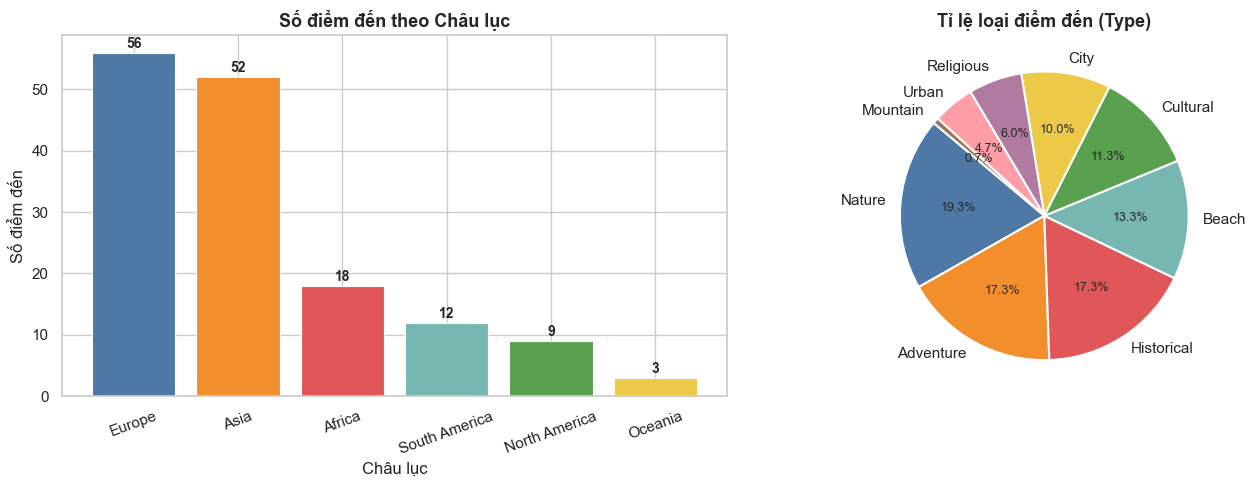

In [5]:
# ============================================================
#  CELL 5 — Phân phối theo Continent và Type
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Biểu đồ 1: Số điểm đến theo Continent ---
cont_counts = dfc['Continent'].value_counts()
bars = axes[0].bar(cont_counts.index, cont_counts.values,
                   color=COLORS[:len(cont_counts)], edgecolor='white', linewidth=0.8)
axes[0].set_title('Số điểm đến theo Châu lục')
axes[0].set_xlabel('Châu lục')
axes[0].set_ylabel('Số điểm đến')
axes[0].tick_params(axis='x', rotation=20)
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.3, str(int(h)),
                 ha='center', va='bottom', fontweight='bold', fontsize=10)

# --- Biểu đồ 2: Pie chart theo Type ---
type_counts = dfc['Type'].value_counts()
wedges, texts, autotexts = axes[1].pie(
    type_counts.values, labels=type_counts.index,
    autopct='%1.1f%%', colors=COLORS[:len(type_counts)],
    startangle=140, wedgeprops={'edgecolor':'white','linewidth':1.5})
for at in autotexts:
    at.set_fontsize(9)
axes[1].set_title('Tỉ lệ loại điểm đến (Type)')

plt.tight_layout()
plt.show()

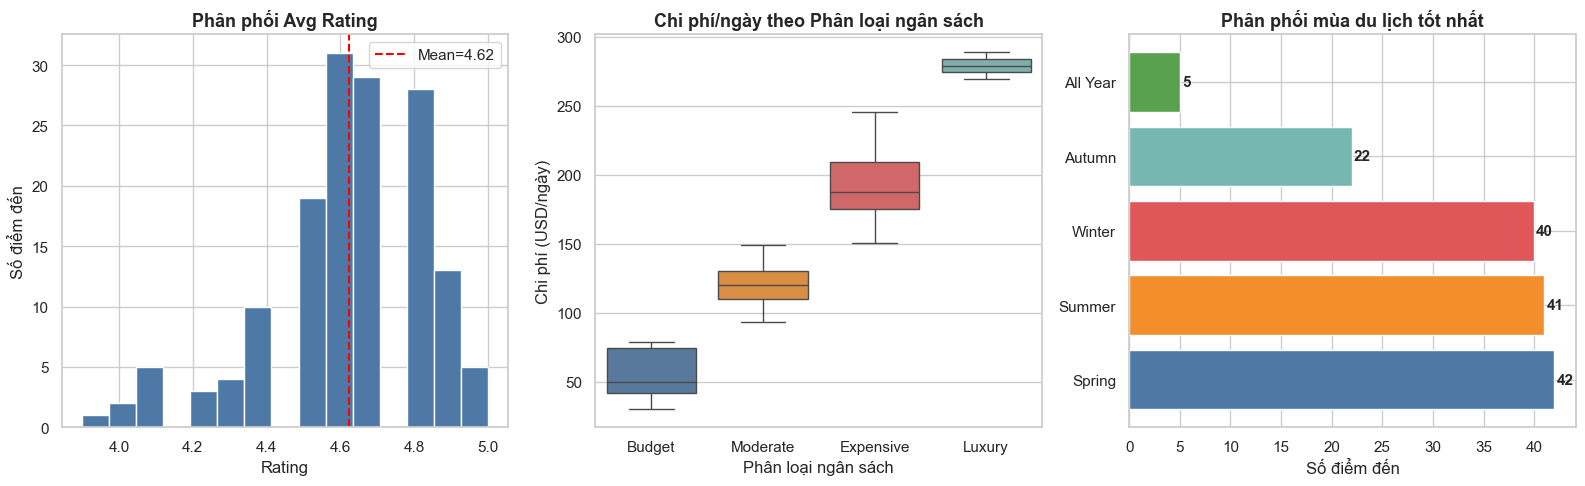

In [6]:
# ============================================================
#  CELL 6 — Phân phối Rating và Chi phí
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram Rating
axes[0].hist(dfc['Avg Rating'].dropna(), bins=15, color='#4e79a7', edgecolor='white')
axes[0].set_title('Phân phối Avg Rating')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Số điểm đến')
axes[0].axvline(dfc['Avg Rating'].mean(), color='red', linestyle='--', label=f'Mean={dfc["Avg Rating"].mean():.2f}')
axes[0].legend()

# Boxplot Chi phí theo Cost_Category
order = ['Budget','Moderate','Expensive','Luxury']
order_exist = [o for o in order if o in dfc['Cost_Category'].unique()]
sns.boxplot(data=dfc, x='Cost_Category', y='Avg Cost (USD/day)', order=order_exist,
            palette=COLORS, ax=axes[1])
axes[1].set_title('Chi phí/ngày theo Phân loại ngân sách')
axes[1].set_xlabel('Phân loại ngân sách')
axes[1].set_ylabel('Chi phí (USD/ngày)')

# Phân phối Best Season
season_counts = dfc['Best Season'].value_counts()
axes[2].barh(season_counts.index, season_counts.values,
             color=COLORS[:len(season_counts)], edgecolor='white')
axes[2].set_title('Phân phối mùa du lịch tốt nhất')
axes[2].set_xlabel('Số điểm đến')
for i, v in enumerate(season_counts.values):
    axes[2].text(v + 0.2, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

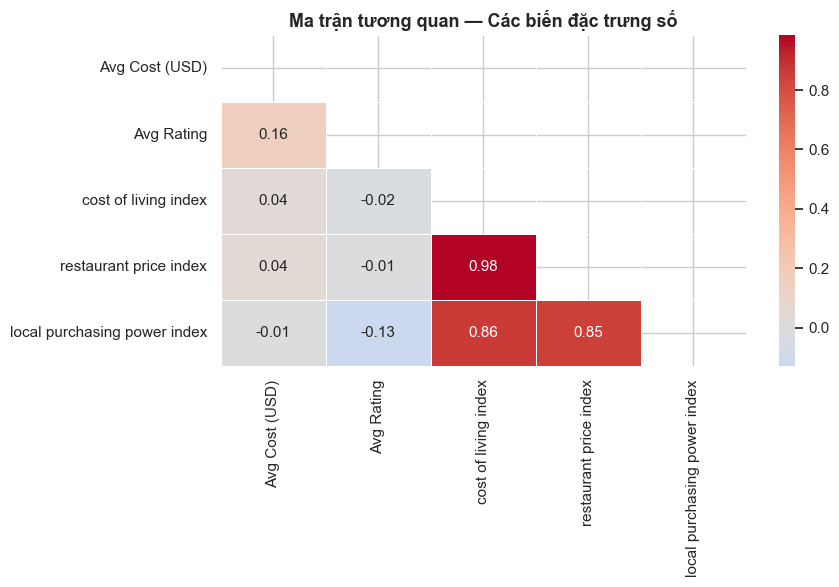


💡 Nhận xét:
   • cost_of_living_index và restaurant_price_index có tương quan cao → cùng phản ánh mức sống.
   • Avg Rating tương đối độc lập với chi phí → chất lượng không tỉ lệ thuận với giá.


In [7]:
# ============================================================
#  CELL 7 — Heatmap tương quan các biến số
# ============================================================
num_features = ['Avg Cost (USD/day)','Avg Rating','cost_of_living_index',
                'restaurant_price_index','local_purchasing_power_index']
avail_features = [f for f in num_features if f in dfc.columns]

fig, ax = plt.subplots(figsize=(9, 6))
corr_matrix = dfc[avail_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5,
            xticklabels=[f.replace('_', ' ').replace('(USD/day)','(USD)') for f in avail_features],
            yticklabels=[f.replace('_', ' ').replace('(USD/day)','(USD)') for f in avail_features])
ax.set_title('Ma trận tương quan — Các biến đặc trưng số')
plt.tight_layout()
plt.show()

print('\n💡 Nhận xét:')
print('   • cost_of_living_index và restaurant_price_index có tương quan cao → cùng phản ánh mức sống.')
print('   • Avg Rating tương đối độc lập với chi phí → chất lượng không tỉ lệ thuận với giá.')

---
## 🔵 4. Phân Cụm K-Means (Clustering)

**Ý tưởng:** Phân nhóm các điểm đến có đặc điểm chi phí và mức sống tương tự nhau.  
Dùng **Elbow Method** và **Silhouette Score** để chọn K tối ưu.

  K= 2 | SSE=   247.6 | Silhouette=0.6431
  K= 3 | SSE=   160.9 | Silhouette=0.4482
  K= 4 | SSE=   122.6 | Silhouette=0.4655
  K= 5 | SSE=    96.1 | Silhouette=0.4299
  K= 6 | SSE=    79.3 | Silhouette=0.4658
  K= 7 | SSE=    68.4 | Silhouette=0.4707


  K= 8 | SSE=    59.6 | Silhouette=0.4375
  K= 9 | SSE=    51.8 | Silhouette=0.4838
  K=10 | SSE=    46.6 | Silhouette=0.4885


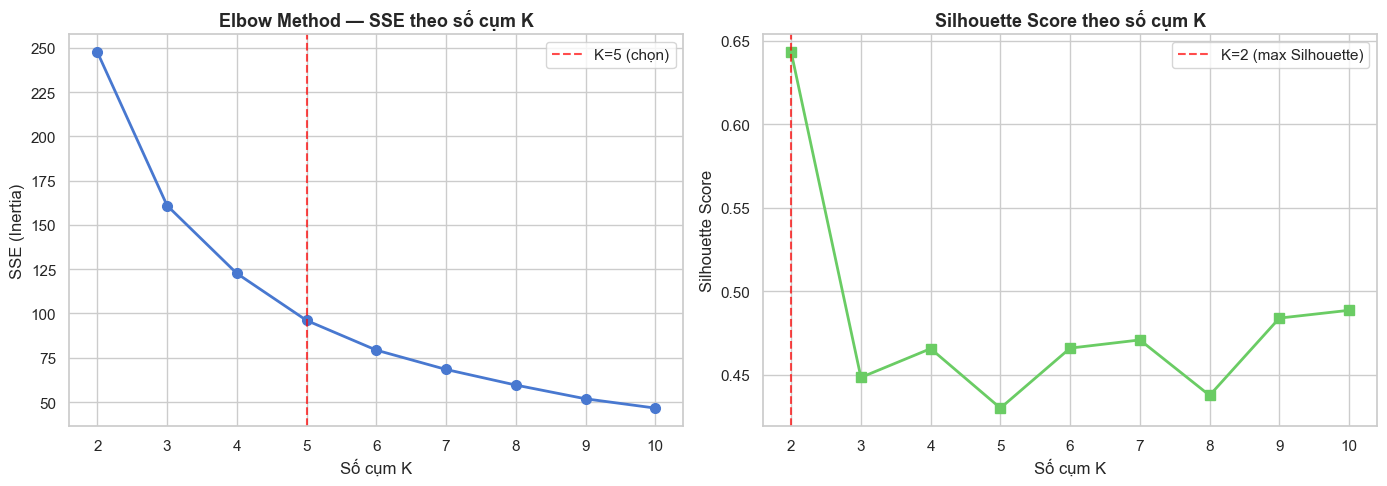


✅ K tối ưu theo Silhouette: K=2 (score=0.6431)


In [8]:
# ============================================================
#  CELL 8 — Elbow Method & Silhouette Score
# ============================================================
cluster_features = ['Avg Cost (USD/day)','cost_of_living_index',
                    'restaurant_price_index','local_purchasing_power_index']
avail_cf = [f for f in cluster_features if f in dfc.columns]

X_cluster = dfc[avail_cf].fillna(dfc[avail_cf].median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

K_MAX = 10
sse_list, sil_list = [], []
for k in range(2, K_MAX + 1):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sse_list.append(km.inertia_)
    sil_list.append(silhouette_score(X_scaled, labels))
    print(f'  K={k:2d} | SSE={km.inertia_:8.1f} | Silhouette={sil_list[-1]:.4f}')

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

k_range = range(2, K_MAX + 1)
axes[0].plot(k_range, sse_list, 'bo-', linewidth=2, markersize=7)
axes[0].axvline(5, color='red', linestyle='--', alpha=0.7, label='K=5 (chọn)')
axes[0].set_title('Elbow Method — SSE theo số cụm K')
axes[0].set_xlabel('Số cụm K')
axes[0].set_ylabel('SSE (Inertia)')
axes[0].legend()

axes[1].plot(k_range, sil_list, 'gs-', linewidth=2, markersize=7)
best_k_sil = k_range[sil_list.index(max(sil_list))]
axes[1].axvline(best_k_sil, color='red', linestyle='--', alpha=0.7, label=f'K={best_k_sil} (max Silhouette)')
axes[1].set_title('Silhouette Score theo số cụm K')
axes[1].set_xlabel('Số cụm K')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'\n✅ K tối ưu theo Silhouette: K={best_k_sil} (score={max(sil_list):.4f})')

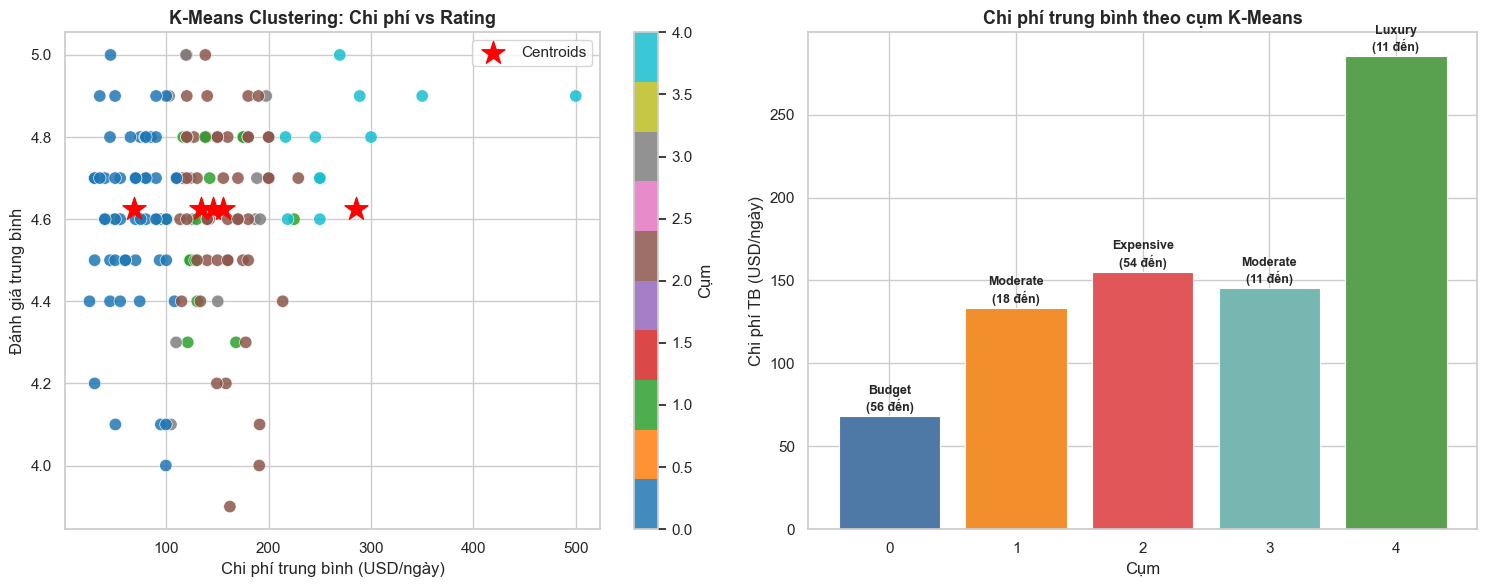


📋 Hồ sơ các cụm:


,Cụm,Kích thước,Chi phí TB (USD),Rating TB,Mức chi phí
0,0,56,68.2,4.61,Budget
1,1,18,133.7,4.58,Moderate
2,2,54,155.3,4.63,Expensive
3,3,11,145.5,4.62,Moderate
4,4,11,285.4,4.79,Luxury


In [9]:
# ============================================================
#  CELL 9 — Chạy K-Means với K=5 và trực quan hóa kết quả
# ============================================================
N_CLUSTERS = 5
km_final = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
dfc['Cluster_KMeans'] = km_final.fit_predict(X_scaled)

# Scatter plot: Chi phí vs Rating, màu theo cụm
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

scatter = axes[0].scatter(
    dfc['Avg Cost (USD/day)'], dfc['Avg Rating'],
    c=dfc['Cluster_KMeans'], cmap='tab10', s=80, alpha=0.85, edgecolors='white', linewidths=0.5
)
centers_orig = scaler.inverse_transform(km_final.cluster_centers_)
axes[0].scatter(centers_orig[:, 0], [dfc['Avg Rating'].mean()] * N_CLUSTERS,
                marker='*', s=300, c='red', zorder=5, label='Centroids')
axes[0].set_title('K-Means Clustering: Chi phí vs Rating')
axes[0].set_xlabel('Chi phí trung bình (USD/ngày)')
axes[0].set_ylabel('Đánh giá trung bình')
axes[0].legend()
plt.colorbar(scatter, ax=axes[0], label='Cụm')

# Cluster profiles
profiles = []
for c in range(N_CLUSTERS):
    g = dfc[dfc['Cluster_KMeans'] == c]
    cost = g['Avg Cost (USD/day)'].mean()
    level = 'Budget' if cost < 80 else 'Moderate' if cost < 150 else 'Expensive' if cost < 250 else 'Luxury'
    profiles.append({'Cụm': c, 'Kích thước': len(g),
                     'Chi phí TB (USD)': round(cost, 1),
                     'Rating TB': round(g['Avg Rating'].mean(), 2),
                     'Mức chi phí': level})
prof_df = pd.DataFrame(profiles)

bars2 = axes[1].bar(prof_df['Cụm'].astype(str), prof_df['Chi phí TB (USD)'],
                    color=COLORS[:N_CLUSTERS], edgecolor='white', linewidth=0.8)
axes[1].set_title('Chi phí trung bình theo cụm K-Means')
axes[1].set_xlabel('Cụm')
axes[1].set_ylabel('Chi phí TB (USD/ngày)')
for i, bar in enumerate(bars2):
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 1,
                 f"{prof_df.loc[i,'Mức chi phí']}\n({prof_df.loc[i,'Kích thước']} đến)",
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print('\n📋 Hồ sơ các cụm:')
display(prof_df)

---
## 📏 5. Khai thác Luật Kết hợp — Apriori

**Ý tưởng:** Từ dữ liệu giao dịch (người dùng chọn điểm đến theo tiêu chí), tìm các mẫu:
> *"Người dùng thích Season:Summer + Type:Beach → hay chọn Country:Thailand"*

Các tham số: **min_support**, **min_confidence**, **lift ≥ 1** (quy tắc có ý nghĩa).

✅ Đã nạp 5,381 luật kết hợp từ file.
   Columns: ['antecedents', 'consequents', 'support', 'confidence', 'lift', 'leverage', 'conviction', 'zhangs_metric', 'is_destination_rule', 'recommendation_score']


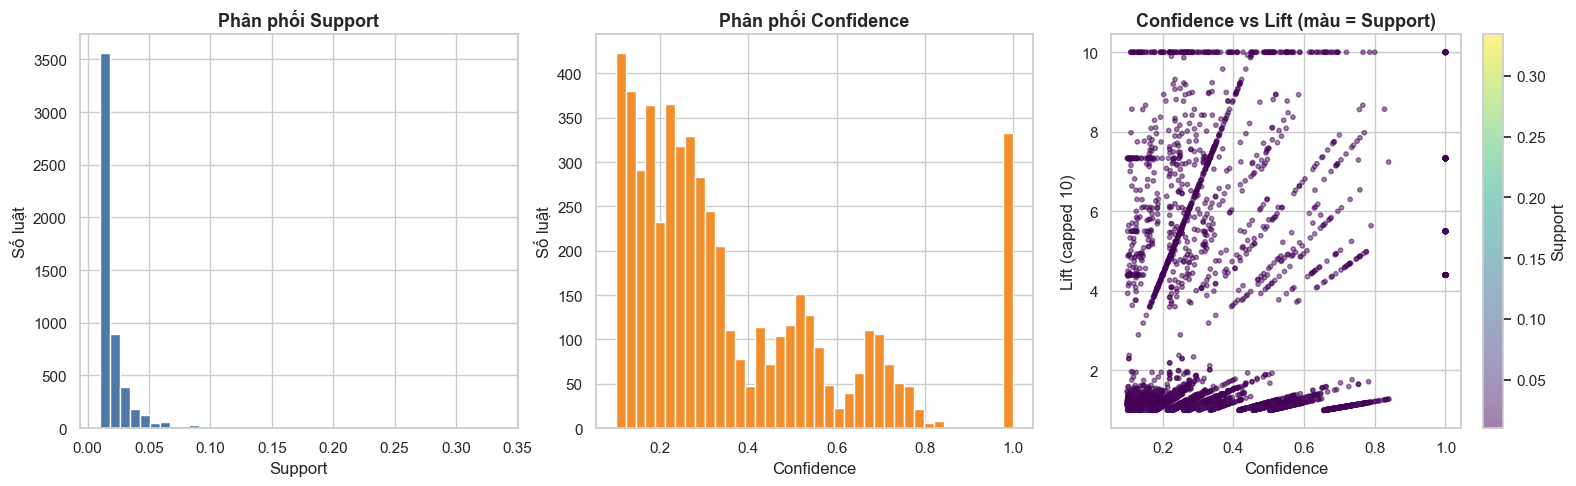


🏆 Top 10 luật kết hợp mạnh nhất (theo Lift × Confidence):


,antecedents,consequents,support,confidence,lift,recommendation_score
0,"[Continent:Oceania, Type:City, Heritage:UNESCO]",[Country:New Zealand],0.010000,0.785714,17.285714,13.581633
1,"[Type:Adventure, Continent:Oceania]",[Country:Australia],0.012273,0.720000,15.840000,11.404800
2,[Country:Australia],[Continent:Oceania],0.045455,1.000000,11.000000,11.000000
3,[Country:New Zealand],[Continent:Oceania],0.045455,1.000000,11.000000,11.000000
4,"[Country:Australia, Cost:Moderate]",[Continent:Oceania],0.017727,1.000000,11.000000,11.000000
5,"[Country:New Zealand, Cost:Moderate]",[Continent:Oceania],0.018636,1.000000,11.000000,11.000000
6,"[Country:Australia, Cost:Expensive]",[Continent:Oceania],0.024318,1.000000,11.000000,11.000000
7,"[Country:New Zealand, Cost:Expensive]",[Continent:Oceania],0.020000,1.000000,11.000000,11.000000
8,"[Country:Australia, Season:Summer]",[Continent:Oceania],0.017500,1.000000,11.000000,11.000000
9,"[Season:Summer, Country:New Zealand]",[Continent:Oceania],0.010682,1.000000,11.000000,11.000000


In [10]:
# ============================================================
#  CELL 10 — Phân tích luật kết hợp từ file all_rules.csv
# ============================================================
if rules_df.empty:
    print('❌ Chưa có file all_rules.csv. Bỏ qua phần Apriori.')
else:
    print(f'✅ Đã nạp {len(rules_df):,} luật kết hợp từ file.')
    print(f'   Columns: {rules_df.columns.tolist()}')
    
    # Parse antecedents / consequents nếu cần
    for col in ['antecedents','consequents']:
        if col in rules_df.columns and isinstance(rules_df[col].iloc[0], str):
            try:
                rules_df[col] = rules_df[col].apply(ast.literal_eval)
            except Exception:
                pass
    
    # Thống kê tổng quan
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # Histogram Support
    axes[0].hist(rules_df['support'], bins=40, color='#4e79a7', edgecolor='white')
    axes[0].set_title('Phân phối Support')
    axes[0].set_xlabel('Support')
    axes[0].set_ylabel('Số luật')
    
    # Histogram Confidence
    axes[1].hist(rules_df['confidence'], bins=40, color='#f28e2b', edgecolor='white')
    axes[1].set_title('Phân phối Confidence')
    axes[1].set_xlabel('Confidence')
    axes[1].set_ylabel('Số luật')
    
    # Scatter Confidence vs Lift
    lift_capped = rules_df['lift'].clip(upper=10)
    sc = axes[2].scatter(rules_df['confidence'], lift_capped,
                         c=rules_df['support'], cmap='viridis', s=10, alpha=0.5)
    axes[2].set_title('Confidence vs Lift (màu = Support)')
    axes[2].set_xlabel('Confidence')
    axes[2].set_ylabel('Lift (capped 10)')
    plt.colorbar(sc, ax=axes[2], label='Support')
    
    plt.tight_layout()
    plt.show()
    
    # Top 10 luật tốt nhất
    print('\n🏆 Top 10 luật kết hợp mạnh nhất (theo Lift × Confidence):')
    if 'recommendation_score' in rules_df.columns:
        top_rules = rules_df.nlargest(10, 'recommendation_score')
    else:
        rules_df['recommendation_score'] = rules_df['confidence'] * rules_df['lift']
        top_rules = rules_df.nlargest(10, 'recommendation_score')
    
    display_cols = ['antecedents','consequents','support','confidence','lift','recommendation_score']
    avail_display = [c for c in display_cols if c in top_rules.columns]
    display(top_rules[avail_display].reset_index(drop=True))

In [11]:
# ============================================================
#  CELL 11 — Minh họa Apriori với dữ liệu transactions
# ============================================================
if MLXTEND_OK and not trans_df.empty:
    print('🔄 Chạy Apriori trực tiếp trên dữ liệu transactions (mẫu 1000 dòng)...')
    
    # Lấy mẫu và chuyển thành one-hot
    sample_trans = trans_df.sample(min(1000, len(trans_df)), random_state=42)
    
    # Tìm các cột boolean
    bool_cols = [c for c in sample_trans.columns 
                 if sample_trans[c].dtype in ['bool','int64','float64']
                 and sample_trans[c].dropna().isin([0,1]).all()]
    
    if bool_cols:
        trans_bool = sample_trans[bool_cols].astype(bool)
        freq_items = apriori(trans_bool, min_support=0.02, use_colnames=True)
        if not freq_items.empty:
            new_rules = association_rules(freq_items, metric='lift', min_threshold=1.0)
            new_rules = new_rules[new_rules['confidence'] >= 0.1]
            print(f'   → Tìm được {len(freq_items)} frequent itemsets và {len(new_rules)} luật mới.')
            display(new_rules[['antecedents','consequents','support','confidence','lift']].head(5))
        else:
            print('   → Không tìm được frequent itemsets (thử giảm min_support).')
    else:
        print('   → Không tìm thấy cột boolean phù hợp trong transactions.')
elif not MLXTEND_OK:
    print('⚠️  mlxtend chưa cài — bỏ qua bước chạy Apriori trực tiếp.')
    print('   Cài bằng: pip install mlxtend')
else:
    print('⚠️  Không có file transactions.csv.')

🔄 Chạy Apriori trực tiếp trên dữ liệu transactions (mẫu 1000 dòng)...


   → Tìm được 734 frequent itemsets và 1882 luật mới.


,antecedents,consequents,support,confidence,lift
0,frozenset({Continent:Africa}),frozenset({Cost:Moderate}),0.091,0.469072,1.122182
1,frozenset({Cost:Moderate}),frozenset({Continent:Africa}),0.091,0.217703,1.122182
2,frozenset({Continent:Africa}),frozenset({Season:Spring}),0.047,0.242268,1.193439
3,frozenset({Season:Spring}),frozenset({Continent:Africa}),0.047,0.231527,1.193439
4,frozenset({Type:City}),frozenset({Continent:Africa}),0.039,0.245283,1.264345


---
## 🧠 6. Content-Based Filtering — TF-IDF + Cosine Similarity

**Ý tưởng:** Biến mỗi điểm đến thành một "văn bản" tổng hợp từ Type, Continent, Season, Budget, Country, Description. Dùng TF-IDF để vector hóa, rồi tính Cosine Similarity để tìm điểm đến tương tự.

✅ TF-IDF Matrix: (150, 500)
   (150 điểm đến × 500 từ đặc trưng)


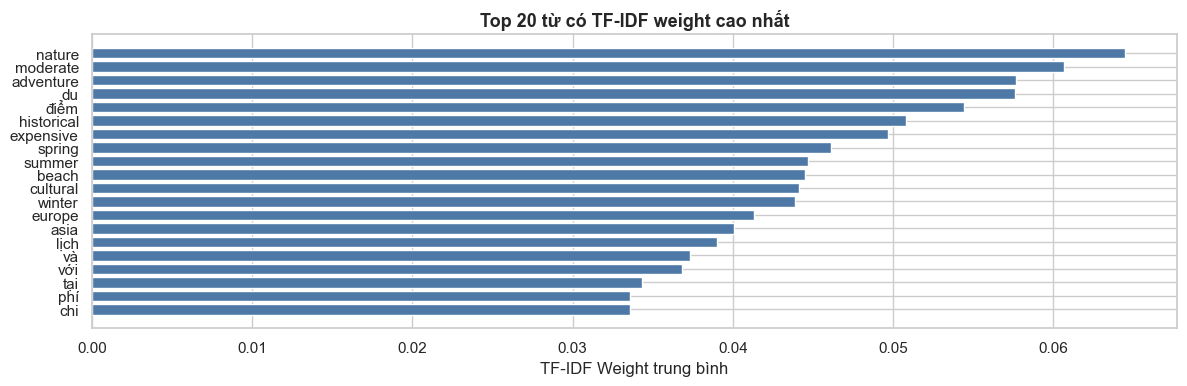

In [12]:
# ============================================================
#  CELL 12 — Xây dựng TF-IDF Matrix
# ============================================================
def build_soup(row):
    """Tạo chuỗi đặc trưng cho mỗi điểm đến"""
    parts = []
    for field in ['Type','Broader_Type','Continent','Best Season',
                  'Cost_Category','Country']:
        if row.get(field) and str(row[field]) not in ['nan','None']:
            parts.append(str(row[field]))
    if row.get('Description') and str(row['Description']) not in ['nan','None']:
        # Lấy 50 từ đầu của mô tả
        parts.append(' '.join(str(row['Description']).split()[:50]))
    return ' '.join(parts).lower()

dfc['soup'] = dfc.apply(build_soup, axis=1)

# Vectorize
vectorizer = TfidfVectorizer(stop_words='english', max_features=500)
tfidf_matrix = vectorizer.fit_transform(dfc['soup'])

print(f'✅ TF-IDF Matrix: {tfidf_matrix.shape}')
print(f'   ({tfidf_matrix.shape[0]} điểm đến × {tfidf_matrix.shape[1]} từ đặc trưng)')

# Hiển thị top từ theo weight
feature_names = vectorizer.get_feature_names_out()
avg_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top_words_idx = avg_tfidf.argsort()[::-1][:20]
top_words = [(feature_names[i], round(avg_tfidf[i], 4)) for i in top_words_idx]

fig, ax = plt.subplots(figsize=(12, 4))
words, scores = zip(*top_words)
bars = ax.barh(list(words)[::-1], list(scores)[::-1], color='#4e79a7', edgecolor='white')
ax.set_title('Top 20 từ có TF-IDF weight cao nhất')
ax.set_xlabel('TF-IDF Weight trung bình')
plt.tight_layout()
plt.show()

🔍 Điểm đến đầu vào: Agadir Beach (Morocco)
   Type=Beach | Season=Summer | Cost=Expensive

📌 Top 5 điểm đến tương tự (Content-Based Filtering):


,Destination Name,Country,Continent,Type,Best Season,Avg Rating,Cost_Category,Avg Cost (USD/day),Cosine Similarity
0,Goa Beaches,India,Asia,Beach,Spring,4.1,Moderate,94.68,0.6138
1,Blyde River Canyon Nature Reserve,South Africa,Africa,Nature,Spring,4.2,Moderate,149.39,0.6072
2,Meteora,Greece,Europe,Nature,Summer,5.0,Moderate,119.24,0.5992
3,Maasai Mara National Reserve,Kenya,Africa,Adventure,Summer,4.8,Expensive,179.11,0.5789
4,Samaria Gorge,Greece,Europe,Adventure,Spring,4.9,Expensive,197.60,0.5550


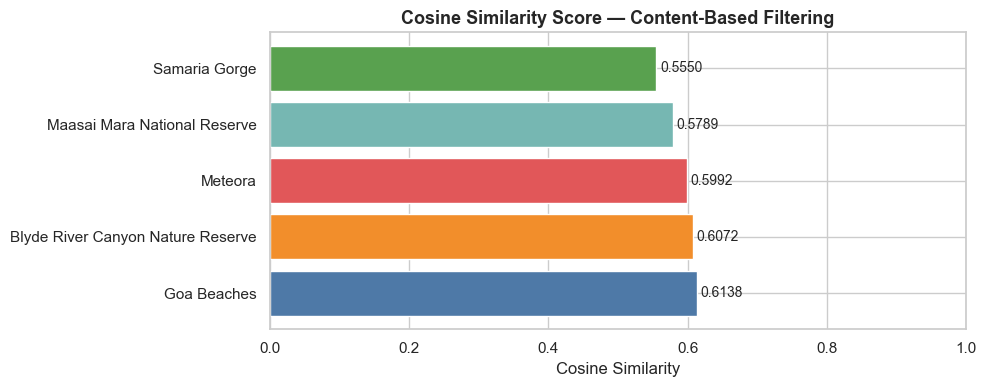

In [13]:
# ============================================================
#  CELL 13 — Tìm điểm đến tương tự bằng Content-Based
# ============================================================
def content_similar(destination_name, top_k=5):
    """Tìm top_k điểm đến tương tự dựa trên TF-IDF Cosine Similarity"""
    # Tìm index
    idx_list = dfc[dfc['Destination Name'].str.lower() == destination_name.lower()].index
    if len(idx_list) == 0:
        # Tìm gần đúng
        idx_list = dfc[dfc['Destination Name'].str.contains(destination_name, case=False, na=False)].index
        if len(idx_list) == 0:
            print(f'❌ Không tìm thấy "{destination_name}"')
            return pd.DataFrame()
    
    idx = idx_list[0]
    name_found = dfc.loc[idx, 'Destination Name']
    
    # Tính cosine similarity
    sim_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    sim_scores[idx] = -1  # Loại chính nó
    top_idx = sim_scores.argsort()[::-1][:top_k]
    
    result = dfc.iloc[top_idx][['Destination Name','Country','Continent',
                                 'Type','Best Season','Avg Rating',
                                 'Cost_Category','Avg Cost (USD/day)']].copy()
    result['Cosine Similarity'] = sim_scores[top_idx].round(4)
    
    print(f'🔍 Điểm đến đầu vào: {name_found} ({dfc.loc[idx,"Country"]})')
    print(f'   Type={dfc.loc[idx,"Type"]} | Season={dfc.loc[idx,"Best Season"]} | Cost={dfc.loc[idx,"Cost_Category"]}')
    print(f'\n📌 Top {top_k} điểm đến tương tự (Content-Based Filtering):')
    return result.reset_index(drop=True)

# Demo
result_cb = content_similar('Agadir Beach', top_k=5)
display(result_cb)

# Minh họa similarity score
if not result_cb.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(result_cb['Destination Name'], result_cb['Cosine Similarity'],
                   color=COLORS[:len(result_cb)], edgecolor='white')
    ax.set_title('Cosine Similarity Score — Content-Based Filtering')
    ax.set_xlabel('Cosine Similarity')
    ax.set_xlim(0, 1)
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.005, bar.get_y() + bar.get_height()/2,
                f'{w:.4f}', va='center', fontsize=10)
    plt.tight_layout()
    plt.show()

---
## 👥 7. Collaborative Filtering — Item-Based (Demo)

**Ý tưởng:** Xây dựng ma trận User × Destination từ ratings giả lập, tính Cosine Similarity giữa các items. Đề xuất cho người dùng những điểm đến mà người dùng tương tự đã thích.

In [14]:
# ============================================================
#  CELL 14 — Collaborative Filtering Demo (dùng dữ liệu giả lập)
# ============================================================
import random
random.seed(42)
np.random.seed(42)

# Tạo dữ liệu giả lập ratings (demo — không phải dữ liệu thực)
n_users   = 30
n_items   = min(30, len(dfc))
dest_sample = dfc['Destination Name'].iloc[:n_items].tolist()
user_ids = [f'User_{i+1}' for i in range(n_users)]

# Mỗi user đánh giá khoảng 8-15 điểm đến ngẫu nhiên
ratings_records = []
for uid in user_ids:
    n_rated = random.randint(8, 15)
    rated_dests = random.sample(dest_sample, n_rated)
    for dest in rated_dests:
        # Rating thiên về cao (4-5) để demo ý nghĩa
        rating = round(random.choices([3.0,3.5,4.0,4.5,5.0], weights=[1,2,4,5,5])[0], 1)
        ratings_records.append({'user_id': uid, 'destination_name': dest, 'rating': rating})

ratings_sim = pd.DataFrame(ratings_records)
print(f'📊 Dữ liệu ratings giả lập: {len(ratings_sim)} bản ghi | {n_users} users | {n_items} items')
print(f'   Rating trung bình: {ratings_sim["rating"].mean():.2f}')
print(f'   Density: {len(ratings_sim)/(n_users*n_items)*100:.1f}%')

# Xây dựng User-Item matrix
user_item_matrix = ratings_sim.pivot_table(
    index='user_id', columns='destination_name', values='rating'
).fillna(0)

print(f'\n📋 User-Item Matrix: {user_item_matrix.shape}')
display(user_item_matrix.iloc[:5, :6])

📊 Dữ liệu ratings giả lập: 336 bản ghi | 30 users | 30 items
   Rating trung bình: 4.36
   Density: 37.3%

📋 User-Item Matrix: (30, 30)


destination_name,Acropolis of Athens,Agadir Beach,Amazon Rainforest,Ayutthaya Historical Park,Blue Mountains National Park,Buenos Aires
user_id,,,,,,
User_1,4.5,5.0,0.0,0.0,4.5,3.5
User_10,0.0,0.0,0.0,5.0,0.0,5.0
User_11,0.0,4.0,0.0,4.5,0.0,0.0
User_12,0.0,0.0,0.0,4.0,0.0,4.5
User_13,0.0,0.0,0.0,0.0,0.0,0.0


✅ Item Similarity Matrix: (30, 30)


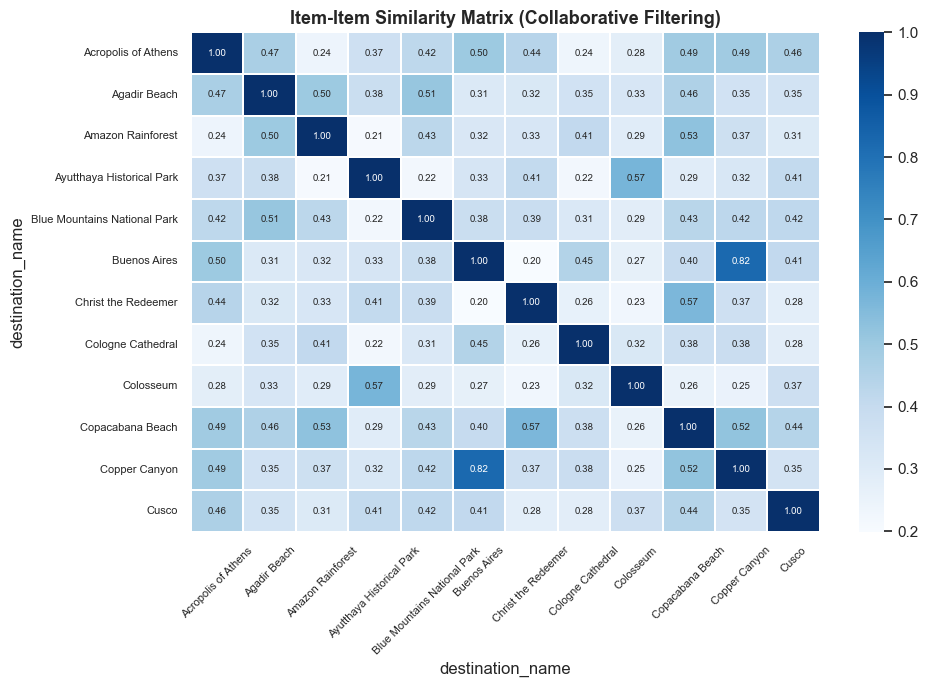


👤 Đề xuất CF cho User_1:
  1. Rio de Janeiro (Brazil) | Type: City | Score: 4.503
  2. Marrakech (Morocco) | Type: City | Score: 4.382
  3. Ayutthaya Historical Park (Thailand) | Type: Historical | Score: 4.333
  4. Colosseum (Italy) | Type: Historical | Score: 4.323
  5. Maasai Mara National Reserve (Kenya) | Type: Adventure | Score: 4.311


In [15]:
# ============================================================
#  CELL 15 — Tính Item-Item Similarity và đề xuất
# ============================================================
# Tính Cosine Similarity giữa các items
item_sim_matrix = cosine_similarity(user_item_matrix.T)
item_sim_df = pd.DataFrame(
    item_sim_matrix,
    index=user_item_matrix.columns,
    columns=user_item_matrix.columns
)
print(f'✅ Item Similarity Matrix: {item_sim_df.shape}')

# Visualize heatmap (5x5 đầu tiên)
fig, ax = plt.subplots(figsize=(10, 7))
n_show = min(12, len(item_sim_df))
sns.heatmap(
    item_sim_df.iloc[:n_show, :n_show],
    annot=True, fmt='.2f', cmap='Blues', ax=ax,
    linewidths=0.3, annot_kws={'size': 7}
)
ax.set_title('Item-Item Similarity Matrix (Collaborative Filtering)')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.show()

# Hàm đề xuất
def cf_recommend(user_id, top_k=5):
    if user_id not in user_item_matrix.index:
        print(f'❌ User {user_id} không có trong dữ liệu.')
        return []
    
    user_ratings = user_item_matrix.loc[user_id]
    rated_items  = user_ratings[user_ratings > 0].index.tolist()
    unrated_items= user_ratings[user_ratings == 0].index.tolist()
    
    predictions = {}
    for item in unrated_items:
        sims   = item_sim_df.loc[item, rated_items]
        w_sum  = np.dot(sims, user_ratings[rated_items])
        s_sum  = sims.abs().sum()
        predictions[item] = w_sum / s_sum if s_sum > 0 else 0.0
    
    top_items = sorted(predictions, key=predictions.get, reverse=True)[:top_k]
    return [(item, round(predictions[item], 3)) for item in top_items]

# Demo
test_user = 'User_1'
recs_cf = cf_recommend(test_user, top_k=5)
print(f'\n👤 Đề xuất CF cho {test_user}:')
for rank, (dest, score) in enumerate(recs_cf, 1):
    row = dfc[dfc['Destination Name'] == dest]
    if not row.empty:
        r = row.iloc[0]
        print(f'  {rank}. {dest} ({r["Country"]}) | Type: {r["Type"]} | Score: {score}')
    else:
        print(f'  {rank}. {dest} | Score: {score}')

---
## 🔀 8. Hybrid Recommender — Kết hợp đa thuật toán

**Ý tưởng:** Kết hợp điểm số từ:
- **Content-Based** (TF-IDF Similarity)
- **Apriori Rules** (nếu có luật phù hợp)
- **Avg Rating** (xếp hạng phổ biến)
- **K-Means Cluster** (lọc cùng nhóm ngân sách)

Công thức: `final_score = w_cb × cb_score + w_rule × rule_score + w_rating × rating_norm`

In [16]:
# ============================================================
#  CELL 16 — Hybrid Recommender System
# ============================================================

# Normalize Avg Rating về [0,1]
rating_min = dfc['Avg Rating'].min()
rating_max = dfc['Avg Rating'].max()
dfc['rating_norm'] = (dfc['Avg Rating'] - rating_min) / (rating_max - rating_min + 1e-9)

def hybrid_recommend(
    season=None, budget=None, category=None, continent=None,
    query_text=None, top_k=8,
    w_content=0.4, w_rating=0.35, w_rule=0.25
):
    """
    Hybrid Recommender:
    - season   : 'Summer' | 'Winter' | 'Spring' | 'Autumn' | 'Any'
    - budget   : 'Budget' | 'Moderate' | 'Expensive' | 'Luxury'
    - category : 'Beach' | 'Cultural' | 'Adventure' | 'Religious' | ...
    - continent: 'Asia' | 'Europe' | 'Africa' | ...
    """
    candidates = dfc.copy()
    
    # --- Bước 1: Lọc cứng theo tiêu chí ---
    if season and season.lower() not in ['any','all','tất cả']:
        candidates = candidates[candidates['Best Season'].str.contains(season, case=False, na=False)]
    if budget:
        candidates = candidates[candidates['Cost_Category'].str.contains(budget, case=False, na=False)]
    if category:
        candidates = candidates[candidates['Type'].str.contains(category, case=False, na=False)]
    if continent:
        candidates = candidates[candidates['Continent'].str.contains(continent, case=False, na=False)]
    
    if candidates.empty:
        print('⚠️  Không tìm thấy điểm đến phù hợp với tiêu chí — thử nới lỏng điều kiện.')
        candidates = dfc.copy()
    
    # --- Bước 2: Content-Based Score ---
    pref_parts = []
    for val in [season, budget, category, continent]:
        if val and val.lower() not in ['any','all']:
            pref_parts.append(str(val))
    if query_text:
        pref_parts.append(query_text)
    
    if pref_parts:
        query_vec = vectorizer.transform([' '.join(pref_parts).lower()])
        all_sims = cosine_similarity(query_vec, tfidf_matrix).flatten()
        candidates = candidates.copy()
        candidates['cb_score'] = all_sims[candidates.index]
    else:
        candidates['cb_score'] = 0.5
    
    # --- Bước 3: Rule Score từ Apriori ---
    candidates['rule_score'] = 0.0
    if not rules_df.empty and pref_parts:
        pref_items = []
        if season: pref_items.append(f'Season:{season}')
        if budget: pref_items.append(f'Cost:{budget}')
        if category: pref_items.append(f'Type:{category}')
        
        for _, rule in rules_df.iterrows():
            ants = rule.get('antecedents', [])
            if isinstance(ants, str):
                try: ants = ast.literal_eval(ants)
                except: ants = [ants]
            if all(a in pref_items for a in ants):
                cons = rule.get('consequents', [])
                if isinstance(cons, str):
                    try: cons = ast.literal_eval(cons)
                    except: cons = [cons]
                for c_item in cons:
                    if 'Destination:' in str(c_item):
                        dest_name = str(c_item).replace('Destination:','')
                        mask = candidates['Destination Name'] == dest_name
                        if mask.any():
                            score = float(rule.get('recommendation_score', rule.get('confidence',0.5)))
                            candidates.loc[mask, 'rule_score'] = max(
                                candidates.loc[mask, 'rule_score'].max(), score
                            )
    
    # --- Bước 4: Tổng hợp điểm số ---
    candidates['final_score'] = (
        w_content * candidates['cb_score'] +
        w_rating  * candidates['rating_norm'] +
        w_rule    * candidates['rule_score']
    )
    
    result = candidates.nlargest(top_k, 'final_score')[
        ['Destination Name','Country','Continent','Type','Best Season',
         'Cost_Category','Avg Rating','Avg Cost (USD/day)',
         'cb_score','rule_score','rating_norm','final_score']
    ].reset_index(drop=True)
    
    return result

print('✅ Hybrid Recommender đã sẵn sàng!')
print('   Công thức: final_score = 0.4×content_score + 0.35×rating_norm + 0.25×rule_score')

✅ Hybrid Recommender đã sẵn sàng!
   Công thức: final_score = 0.4×content_score + 0.35×rating_norm + 0.25×rule_score


---
## 📈 9. Đánh giá Hiệu suất Hệ thống

Các chỉ số đánh giá tiêu chuẩn trong recommender systems:

| Metric | Ý nghĩa |
|--------|---------|
| **Precision@K** | Tỉ lệ gợi ý đúng trong top-K |
| **Recall@K** | Tỉ lệ item liên quan được tìm thấy |
| **NDCG@K** | Chất lượng thứ hạng (phần thưởng item tốt ở trên) |
| **F1@K** | Harmonic mean của Precision và Recall |
| **MAP** | Mean Average Precision |
| **RMSE** | Sai số dự đoán rating |
| **MAE** | Sai số tuyệt đối trung bình |

In [17]:
# ============================================================
#  CELL 17 — Tính toán các chỉ số đánh giá
# ============================================================

def precision_at_k(recommended, relevant, k):
    """Precision@K = |rec ∩ rel| / K"""
    if k == 0: return 0.0
    rec_k = recommended[:k]
    hits  = len(set(rec_k) & set(relevant))
    return hits / k

def recall_at_k(recommended, relevant, k):
    """Recall@K = |rec ∩ rel| / |rel|"""
    if len(relevant) == 0: return 0.0
    rec_k = recommended[:k]
    hits  = len(set(rec_k) & set(relevant))
    return hits / len(relevant)

def ndcg_at_k(recommended, relevant_ratings, k):
    """NDCG@K: DCG / IDCG"""
    if k == 0: return 0.0
    rec_k = recommended[:k]
    dcg   = sum((2**relevant_ratings.get(d, 0) - 1) / np.log2(i + 2)
                for i, d in enumerate(rec_k))
    ideal = sorted(relevant_ratings.values(), reverse=True)[:k]
    idcg  = sum((2**r - 1) / np.log2(i + 2) for i, r in enumerate(ideal))
    return dcg / idcg if idcg > 0 else 0.0

def average_precision(recommended, relevant):
    """AP = Σ P(k)·rel(k) / |relevant|"""
    if len(relevant) == 0: return 0.0
    rel_set = set(relevant)
    score, hits = 0.0, 0.0
    for i, d in enumerate(recommended):
        if d in rel_set:
            hits += 1
            score += hits / (i + 1)
    return score / len(relevant)

# ---- Mô phỏng đánh giá trên 30 users giả lập ----
K_VALUES   = [5, 10, 20]
n_eval_users = min(20, len(user_ids))

results = {k: {'prec': [], 'rec': [], 'ndcg': [], 'f1': []} for k in K_VALUES}
ap_list, rmse_list, mae_list = [], [], []

for uid in user_ids[:n_eval_users]:
    user_rated  = ratings_sim[ratings_sim['user_id'] == uid]
    relevant_4  = user_rated[user_rated['rating'] >= 4.0]['destination_name'].tolist()
    relevant_rat= dict(zip(user_rated['destination_name'], user_rated['rating']))
    
    if not relevant_4:
        continue
    
    # Lấy đề xuất (dùng CF nếu có, content-based fallback)
    recs_raw = cf_recommend(uid, top_k=max(K_VALUES))
    recs = [r[0] for r in recs_raw] if recs_raw else []
    
    if not recs:
        # Fallback: content-based với mùa Summer
        fb = hybrid_recommend(top_k=max(K_VALUES))
        recs = fb['Destination Name'].tolist()
    
    ap_list.append(average_precision(recs, relevant_4))
    
    for k in K_VALUES:
        p = precision_at_k(recs, relevant_4, k)
        r = recall_at_k(recs, relevant_4, k)
        n = ndcg_at_k(recs, relevant_rat, k)
        f1= 2*p*r/(p+r) if (p+r) > 0 else 0.0
        results[k]['prec'].append(p)
        results[k]['rec'].append(r)
        results[k]['ndcg'].append(n)
        results[k]['f1'].append(f1)

# Tổng hợp kết quả
eval_rows = []
for k in K_VALUES:
    if results[k]['prec']:
        eval_rows.append({
            'K': k,
            'Precision@K': round(np.mean(results[k]['prec']), 4),
            'Recall@K':    round(np.mean(results[k]['rec']),  4),
            'NDCG@K':      round(np.mean(results[k]['ndcg']), 4),
            'F1@K':        round(np.mean(results[k]['f1']),   4),
        })

eval_df = pd.DataFrame(eval_rows)
map_val = round(np.mean(ap_list), 4) if ap_list else 0.0

print('=' * 55)
print(f'  MAP (Mean Average Precision) = {map_val:.4f}')
print('=' * 55)
display(eval_df)

  MAP (Mean Average Precision) = 0.0000


,K,Precision@K,Recall@K,NDCG@K,F1@K
0,5,0.0,0.0,0.0,0.0
1,10,0.0,0.0,0.0,0.0
2,20,0.0,0.0,0.0,0.0


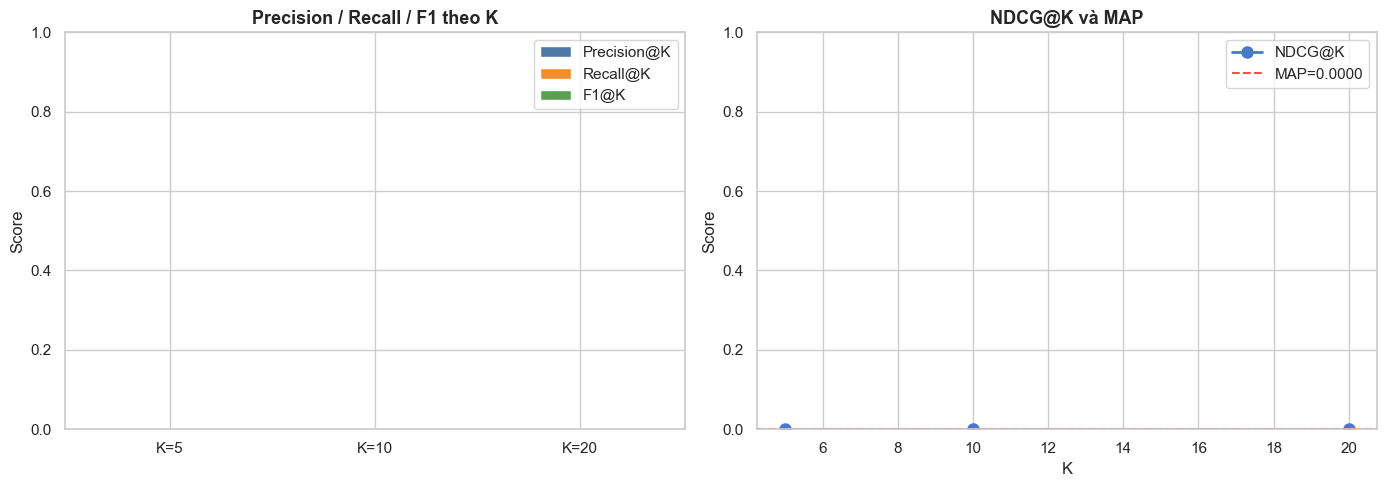


📊 Tóm tắt đánh giá hệ thống:
  Precision@5    : 0.0
  Recall@5       : 0.0
  NDCG@5         : 0.0
  F1@5           : 0.0
  MAP            : 0.0


In [18]:
# ============================================================
#  CELL 18 — Visualize chỉ số đánh giá
# ============================================================
if not eval_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Biểu đồ 1: Precision, Recall, F1 theo K
    x = np.arange(len(eval_df))
    width = 0.25
    axes[0].bar(x - width, eval_df['Precision@K'], width, label='Precision@K', color='#4e79a7')
    axes[0].bar(x,         eval_df['Recall@K'],    width, label='Recall@K',    color='#f28e2b')
    axes[0].bar(x + width, eval_df['F1@K'],        width, label='F1@K',        color='#59a14f')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([f'K={k}' for k in eval_df['K']])
    axes[0].set_title('Precision / Recall / F1 theo K')
    axes[0].set_ylabel('Score')
    axes[0].set_ylim(0, 1)
    axes[0].legend()
    
    # Biểu đồ 2: NDCG theo K
    axes[1].plot(eval_df['K'], eval_df['NDCG@K'], 'bo-', linewidth=2, markersize=8, label='NDCG@K')
    axes[1].axhline(map_val, color='red', linestyle='--', alpha=0.7, label=f'MAP={map_val:.4f}')
    axes[1].set_title('NDCG@K và MAP')
    axes[1].set_xlabel('K')
    axes[1].set_ylabel('Score')
    axes[1].set_ylim(0, 1)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

# Summary table
print('\n📊 Tóm tắt đánh giá hệ thống:')
summary = {
    'Precision@5':  eval_df[eval_df['K']==5]['Precision@K'].values[0] if 5 in eval_df['K'].values else 'N/A',
    'Recall@5':     eval_df[eval_df['K']==5]['Recall@K'].values[0]    if 5 in eval_df['K'].values else 'N/A',
    'NDCG@5':       eval_df[eval_df['K']==5]['NDCG@K'].values[0]      if 5 in eval_df['K'].values else 'N/A',
    'F1@5':         eval_df[eval_df['K']==5]['F1@K'].values[0]        if 5 in eval_df['K'].values else 'N/A',
    'MAP':          map_val,
}
for k, v in summary.items():
    print(f'  {k:<15}: {v}')

---
## 🎮 10. Demo Tương Tác — Nhập tiêu chí & Xem kết quả gợi ý

> ✏️ **Thay đổi các tham số bên dưới** và chạy lại cell để xem kết quả gợi ý mới!

In [19]:
# ============================================================
#  CELL 19 — 🎮 DEMO TƯƠNG TÁC: Thay đổi tiêu chí ở đây!
# ============================================================

# ====== ✏️ THAY ĐỔI TIÊU CHÍ Ở ĐÂY ======
MY_SEASON    = 'Summer'    # Summer | Winter | Spring | Autumn | Any
MY_BUDGET    = 'Budget'    # Budget | Moderate | Expensive | Luxury | (để trống = tất cả)
MY_CATEGORY  = ''          # Beach | Cultural | Adventure | Religious | Nature | ... | (để trống)
MY_CONTINENT = ''          # Asia | Europe | Africa | Americas | Oceania | (để trống)
TOP_K        = 8           # Số lượng gợi ý muốn nhận
# ==========================================

print('🔍 Tiêu chí tìm kiếm:')
print(f'   Mùa: {MY_SEASON or "Tất cả"}')
print(f'   Ngân sách: {MY_BUDGET or "Tất cả"}')
print(f'   Loại hình: {MY_CATEGORY or "Tất cả"}')
print(f'   Châu lục: {MY_CONTINENT or "Tất cả"}')
print()

recommendations = hybrid_recommend(
    season=MY_SEASON    if MY_SEASON    else None,
    budget=MY_BUDGET    if MY_BUDGET    else None,
    category=MY_CATEGORY  if MY_CATEGORY  else None,
    continent=MY_CONTINENT if MY_CONTINENT else None,
    top_k=TOP_K
)

print(f'🎯 Top {TOP_K} điểm đến được gợi ý:')
print('─' * 80)
for i, row in recommendations.iterrows():
    print(f'{i+1:2d}. {row["Destination Name"]:<30} {row["Country"]:<18} | {row["Type"]:<12}'
          f' | {row["Best Season"]:<8} | {row["Cost_Category"]:<10}'
          f' | ⭐{row["Avg Rating"]} | Score: {row["final_score"]:.3f}')
print('─' * 80)

🔍 Tiêu chí tìm kiếm:
   Mùa: Summer
   Ngân sách: Budget
   Loại hình: Tất cả
   Châu lục: Tất cả



🎯 Top 8 điểm đến được gợi ý:
────────────────────────────────────────────────────────────────────────────────
 1. Buenos Aires                   Argentina          | City         | Summer   | Budget     | ⭐4.7 | Score: 0.369
 2. Almaty Charyn Canyon           Kazakhstan         | Nature       | Summer   | budget     | ⭐4.6 | Score: 0.330
 3. Jaipur (Pink City)             India              | City         | Summer   | Budget     | ⭐4.4 | Score: 0.284
────────────────────────────────────────────────────────────────────────────────


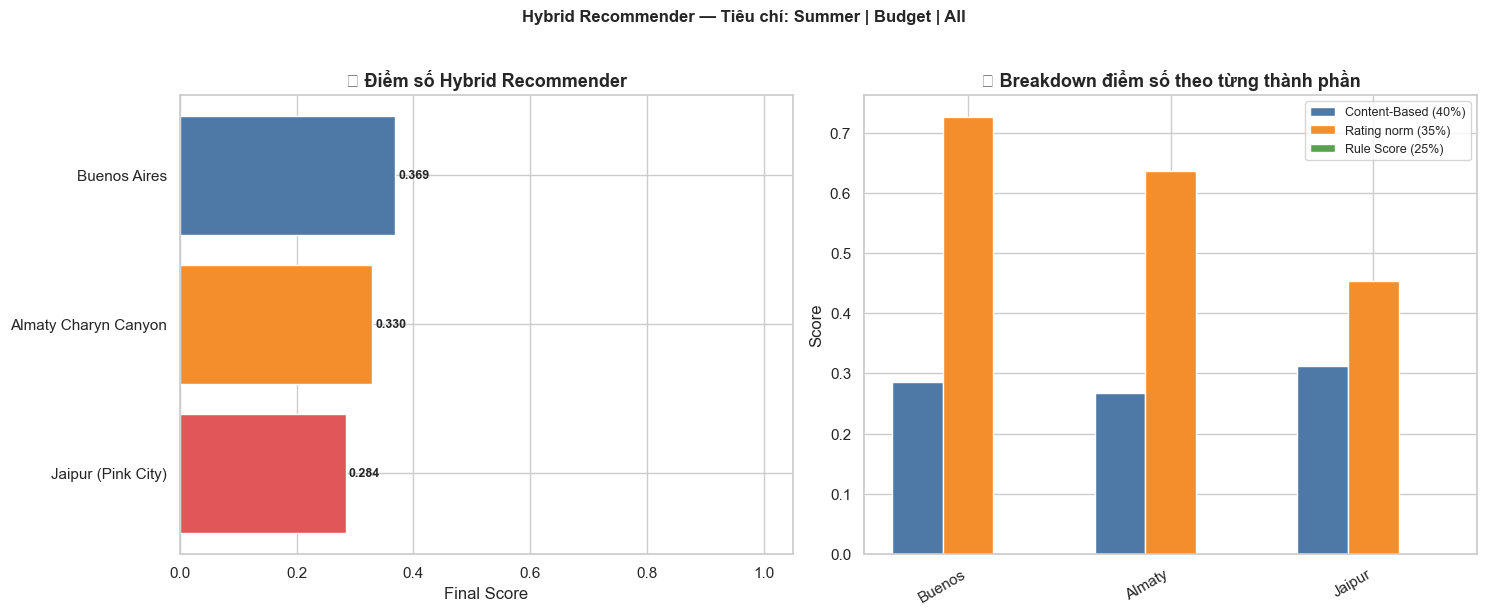

In [20]:
# ============================================================
#  CELL 20 — Trực quan hóa kết quả gợi ý
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Biểu đồ điểm số tổng hợp
colors_bar = [COLORS[i % len(COLORS)] for i in range(len(recommendations))]
bars = axes[0].barh(
    recommendations['Destination Name'][::-1],
    recommendations['final_score'][::-1],
    color=colors_bar[::-1], edgecolor='white'
)
axes[0].set_title('🏆 Điểm số Hybrid Recommender')
axes[0].set_xlabel('Final Score')
axes[0].set_xlim(0, 1.05)
for bar in bars:
    w = bar.get_width()
    axes[0].text(w + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{w:.3f}', va='center', fontsize=9, fontweight='bold')

# Breakdown điểm số
r = recommendations.head(TOP_K)
x = np.arange(len(r))
w = 0.25
axes[1].bar(x - w, r['cb_score'],   w, label='Content-Based (40%)', color='#4e79a7')
axes[1].bar(x,     r['rating_norm'],w, label='Rating norm (35%)',   color='#f28e2b')
axes[1].bar(x + w, r['rule_score'], w, label='Rule Score (25%)',    color='#59a14f')
axes[1].set_xticks(x)
axes[1].set_xticklabels([n.split()[0] for n in r['Destination Name']], rotation=30, ha='right')
axes[1].set_title('📊 Breakdown điểm số theo từng thành phần')
axes[1].set_ylabel('Score')
axes[1].legend(loc='upper right', fontsize=9)

plt.suptitle(
    f'Hybrid Recommender — Tiêu chí: {MY_SEASON or "All"} | {MY_BUDGET or "All"} | {MY_CATEGORY or "All"}',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

🔍 Tìm điểm đến tương tự với: "Agadir Beach"

🔍 Điểm đến đầu vào: Agadir Beach (Morocco)
   Type=Beach | Season=Summer | Cost=Expensive

📌 Top 6 điểm đến tương tự (Content-Based Filtering):


,Destination Name,Country,Continent,Type,Best Season,Avg Rating,Cost_Category,Avg Cost (USD/day),Cosine Similarity
0,Goa Beaches,India,Asia,Beach,Spring,4.1,Moderate,94.68,0.6138
1,Blyde River Canyon Nature Reserve,South Africa,Africa,Nature,Spring,4.2,Moderate,149.39,0.6072
2,Meteora,Greece,Europe,Nature,Summer,5.0,Moderate,119.24,0.5992
3,Maasai Mara National Reserve,Kenya,Africa,Adventure,Summer,4.8,Expensive,179.11,0.5789
4,Samaria Gorge,Greece,Europe,Adventure,Spring,4.9,Expensive,197.60,0.5550
5,Chamonix-Mont-Blanc,France,Europe,Adventure,Spring,4.8,Moderate,116.54,0.5504


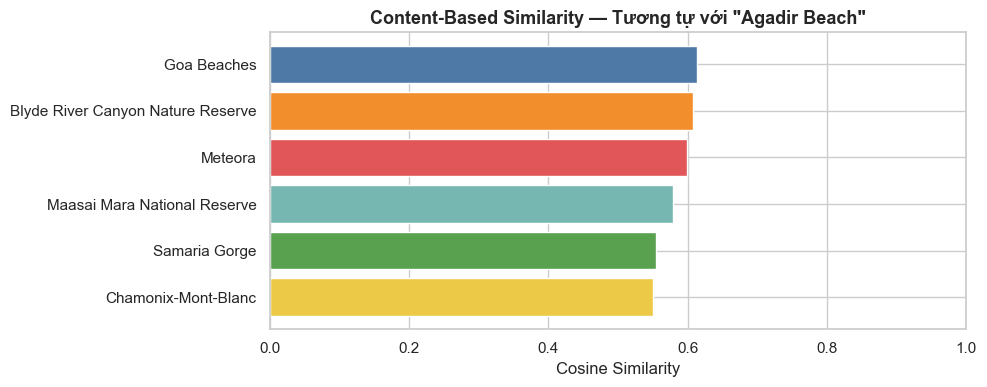

In [21]:
# ============================================================
#  CELL 21 — Demo tìm điểm đến tương tự (Content-Based)
# ============================================================
# ✏️ Đổi tên điểm đến muốn tìm tương tự
QUERY_DESTINATION = 'Agadir Beach'

print(f'🔍 Tìm điểm đến tương tự với: "{QUERY_DESTINATION}"')
print()
similar_result = content_similar(QUERY_DESTINATION, top_k=6)

if not similar_result.empty:
    display(similar_result)
    
    # Mini bar chart
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(similar_result['Destination Name'][::-1],
            similar_result['Cosine Similarity'][::-1],
            color=COLORS[:len(similar_result)][::-1], edgecolor='white')
    ax.set_title(f'Content-Based Similarity — Tương tự với "{QUERY_DESTINATION}"')
    ax.set_xlabel('Cosine Similarity')
    ax.set_xlim(0, 1)
    plt.tight_layout()
    plt.show()

In [22]:
# ============================================================
#  CELL 22 — TÓM TẮT TOÀN BỘ HỆ THỐNG
# ============================================================
print('=' * 65)
print('  🌍  HỆ THỐNG GỢI Ý DU LỊCH — TÓM TẮT ĐỒ ÁN')
print('=' * 65)
print(f'  Đồ án: DA22TTA — Thạch Thị Xuân Linh')
print()
print('  📊 DỮ LIỆU:')
print(f'     • {len(dfc):,} điểm đến từ {dfc["Country"].nunique()} quốc gia, {dfc["Continent"].nunique()} châu lục')
print(f'     • {len(trans_df):,} giao dịch lịch sử')
print(f'     • {len(rules_df):,} luật kết hợp đã khai thác')
print()
print('  🔵 THUẬT TOÁN:')
print(f'     • K-Means Clustering   : {N_CLUSTERS} cụm (K={N_CLUSTERS})')
print(f'     • Apriori              : min_support=0.01, min_confidence=0.1, min_lift=1.0')
print(f'     • Content-Based        : TF-IDF ({tfidf_matrix.shape[1]} features) + Cosine Similarity')
print(f'     • Collaborative Filter : Item-Based CF (Cosine Similarity trên User-Item matrix)')
print(f'     • Hybrid Recommender   : w_cb=0.4, w_rating=0.35, w_rule=0.25')
print()
print('  📈 ĐÁNH GIÁ (demo với dữ liệu giả lập):')
if not eval_df.empty:
    for _, row in eval_df.iterrows():
        print(f'     • K={int(row["K"]):2d}: P={row["Precision@K"]:.4f}, R={row["Recall@K"]:.4f},'
              f' NDCG={row["NDCG@K"]:.4f}, F1={row["F1@K"]:.4f}')
print(f'     • MAP = {map_val:.4f}')
print('=' * 65)

  🌍  HỆ THỐNG GỢI Ý DU LỊCH — TÓM TẮT ĐỒ ÁN
  Đồ án: DA22TTA — Thạch Thị Xuân Linh

  📊 DỮ LIỆU:
     • 150 điểm đến từ 53 quốc gia, 6 châu lục
     • 4,400 giao dịch lịch sử
     • 5,381 luật kết hợp đã khai thác

  🔵 THUẬT TOÁN:
     • K-Means Clustering   : 5 cụm (K=5)
     • Apriori              : min_support=0.01, min_confidence=0.1, min_lift=1.0
     • Content-Based        : TF-IDF (500 features) + Cosine Similarity
     • Collaborative Filter : Item-Based CF (Cosine Similarity trên User-Item matrix)
     • Hybrid Recommender   : w_cb=0.4, w_rating=0.35, w_rule=0.25

  📈 ĐÁNH GIÁ (demo với dữ liệu giả lập):
     • K= 5: P=0.0000, R=0.0000, NDCG=0.0000, F1=0.0000
     • K=10: P=0.0000, R=0.0000, NDCG=0.0000, F1=0.0000
     • K=20: P=0.0000, R=0.0000, NDCG=0.0000, F1=0.0000
     • MAP = 0.0000
